<a href="https://colab.research.google.com/github/aditnikhilmbt23-glitch/Bioinfo-lab/blob/main/Restriction_mapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 19.4 MB/s eta 0:00:00


In [ ]:
import os
from Bio import Entrez, SeqIO, Restriction
from Bio.Seq import Seq

# --- Function to Auto-Analyze a GenBank File ---
def auto_restriction_analysis(accession_id):
    Entrez.email = "adv@gmail.com" # <--- Put a dummy email here

    print(f"📡 Fetching GenBank record for {accession_id}...")

    try:
        # 1. Fetch the GenBank file (contains sequence AND coordinates)
        handle = Entrez.efetch(db="nucleotide", id=accession_id, rettype="gb", retmode="text")
        record = SeqIO.read(handle, "genbank")
        handle.close()

        dna_seq = record.seq
        print(f"✅ Download complete. Sequence Length: {len(dna_seq)} bp")

        # 2. Find the Gene/CDS Location automatically
        goi_start = 0
        goi_end = 0
        found_cds = False

        print("\n🔍 Scanning file for Gene coordinates...")
        for feature in record.features:
            if feature.type == "CDS": # CDS = Coding Sequence (the actual gene part)
                # Biopython uses 0-based indexing, usually what we want for python slicing
                goi_start = int(feature.location.start)
                goi_end = int(feature.location.end)
                found_cds = True
                print(f"   Found CDS! Location: {goi_start} to {goi_end}")
                break # We usually just want the main coding region

        if not found_cds:
            print("⚠️ Warning: No 'CDS' feature found. Treating entire sequence as GOI.")
            goi_end = len(dna_seq)

        # 3. Perform Restriction Mapping
        print("\n✂️  Running Restriction Mapping...")
        print("-" * 60)
        print(f"{'Enzyme':<10} | {'Status':<10} | {'Cut Sites'}")
        print("-" * 60)

        # Define enzymes
        enzyme_batch = Restriction.RestrictionBatch(["EcoRI", "BamHI", "HindIII", "NotI", "XbaI", "AluI"])
        results = enzyme_batch.search(dna_seq)

        for enzyme, cuts in results.items():
            # Check Safety
            is_safe = True
            unsafe_cuts = []

            for cut in cuts:
                # Check if cut is INSIDE the gene (Bad!)
                if goi_start <= cut <= goi_end:
                    is_safe = False

            status = "✅ SAFE" if is_safe else "❌ UNSAFE"

            # Format output
            cut_str = str(sorted(cuts)) if cuts else "No cuts"
            if len(cut_str) > 30: cut_str = cut_str[:30] + "..." # Truncate long lists

            print(f"{str(enzyme):<10} | {status:<10} | {cut_str}")

    except Exception as e:
        print(f"Error: {e}")

# --- Main Execution ---
# You can use "NM_000546" (TP53 - Tumor Protein 53 (Known as the "Guardian of the Genome." It is the most frequently mutated gene in human cancers.)) or any other ID you used before
print("Enter NCBI Accession ID (e.g., NM_000546):")
acc_id = input().strip()

auto_restriction_analysis(acc_id)

Enter NCBI Accession ID (e.g., NM_000546):
NM_000546
📡 Fetching GenBank record for NM_000546...
✅ Download complete. Sequence Length: 2512 bp

🔍 Scanning file for Gene coordinates...
   Found CDS! Location: 142 to 1324

✂️  Running Restriction Mapping...
------------------------------------------------------------
Enzyme     | Status     | Cut Sites
------------------------------------------------------------
EcoRI      | ✅ SAFE     | No cuts
NotI       | ✅ SAFE     | No cuts
XbaI       | ✅ SAFE     | [10, 1812]
BamHI      | ✅ SAFE     | [2034]
HindIII    | ✅ SAFE     | No cuts
AluI       | ❌ UNSAFE   | [38, 330, 378, 460, 575, 949, ...


How is it diff from NEB webcutter:

1. this code runs many genes together but webcutter cant, as it only runs each gene individually.
2. this code ignores methylation, webcutter finds the dcm ordam changes that are made in a bacteria and then give restriction site, but we cant do that as this code only reads the dna seq and a a string of letters and doesnt know of dcm or dam changes, but why cant we do that as the webcutter updates dynamically and is updated on all the changes and new sites found by new compaines when they are released, but this code is static and wont get updated everytime that hapoens as it is just for study and understanding sake of how it maps a gene and finds the RE sites.

how it works:
1. it takes a dummy mail.
2. enters ncbi site and searches for the accession id, user has provided, and gets he Genbank file of it( why gen bank file and not fasta file? As genbank file has info about where the CDS region is and where a specific goi is so the code will know that if RE cuts are found in CDS region it will mark it as unsafe)
3. analyses the dna seq, finds the RE sites based on the dataset of RE we have provided from biopython. and searches for these RE sites.
4. checks if these RE sites are in CDS region or not. if in CDS region the it is marked as unsafe and a list of where all there sites are present is give. if RE site is NOT in cds region, the RE site is marked as safe and the locations are given to the user as output.

Algo:
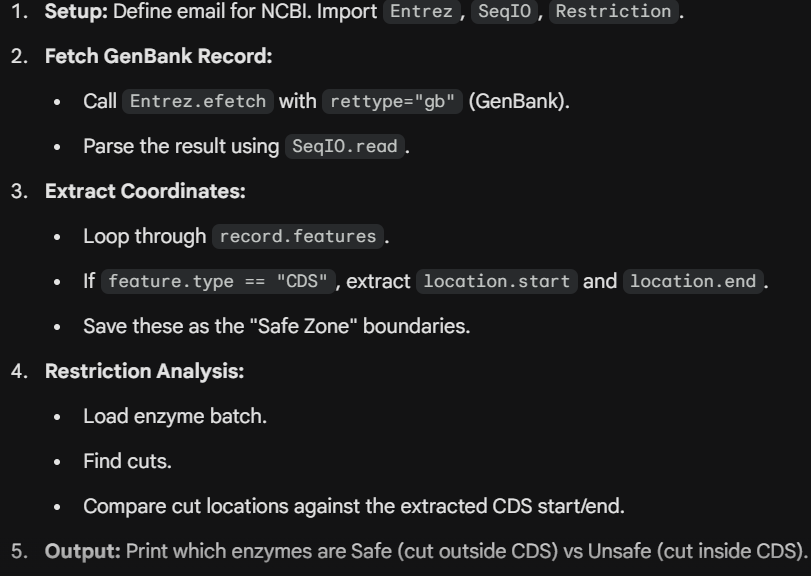